# Analiza za 9.9.2026, colormaps za EI 2 baths in fixed point T1, T2 check z equivalent T

Za logs + saved files sta fixed_baths.py in phase_map_plots.py

In [154]:
import sys
from pathlib import Path
import tqdm.notebook as tqdm 
import numpy as np
import yaml
import jax

ROOT = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths")
CFG = ROOT / "config" / "config_phonons.yaml"


import EI.ei_unified as eu
from phase_map_plots import plot_maps, scan_maps
from fixed_baths import (
    plot_bz,
    plot_dispersion,
    plot_energy,
    plot_xi,
    solve_state,
    solve_teff,
)
from utils.cosmetics import apply_plt_style
from utils.logger import logger
from utils.plotting_utils import Plotter
import EI.ei_unified as eu
import EI.ei_jax_2 as ej
import EI.ei_phonon as pb

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map
from fixed_baths import k_path, take_path, color_line, solve_state, plot_dispersion


apply_plt_style()
pt = Plotter(show=True, close=False)

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [155]:
import matplotlib.pyplot as plt
import colormaps as cmaps
import jax.numpy as jnp
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
from utils.cosmetics import SET1_LIST

In [156]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]
nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)
p = eu.MFPars(**md["mean_field"])

In [157]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])
d0 = max(abs(float(s0.d)), 1.0e-12)
m0 = float(s0.m)
tc = float(eu.critical_temperature(bd_ref, p, **eq["critical"]))

logger.info("Delta_0 = %.8f", d0)
logger.info("m_0 = %.8f", m0)
logger.info("T_c = %.8f", tc)

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[20:07:32] [INFO    ] Delta_0 = 1.00005168
[20:07:32] [INFO    ] m_0 = -0.68433834
[20:07:32] [INFO    ] T_c = 0.53523542


In [158]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

st = ej.mf_state(bd_ref, p, s0.d, s0.m)
t1n, t2n = 6.4, 0.2
t1, t2 = t1n * tc, t2n * tc

In [194]:

bc = op["bath"]
fn = getattr(pb, bc["rate"])
bp = dict(bc["pars"])

ov = ({"w0": 5.5}, {"w0": 2.5})     # bath 1 (T1), bath 2 (T2)

bs = tuple(
    fn(t, bd.k, name=f"bath_{i + 1}", **{**bp, **o})
    for i, (t, o) in enumerate(zip((t1, t2), ov))
)

es = {**eq["solve"], "prog": False}
se = eu.solve_eq(
    bd, p,
    t=t2,
    d=max(abs(d0), 1.0e-8),
    m=m0,
    **es,
)

sk = {
    "mix": (0.1, 0.1, 0.1),
    "tol": 1.0e-4,
    "nmax": 20000,
    "chk": 50,
    "prog": True,
}

so = ej.solve_fixed(
    bd, p, se.n.copy(), bs,
    d=float(se.d),
    m=float(se.m),
    **sk,
)

st = ej.mf_state(
    bd, p,
    d=float(so.d),
    m=float(so.m),
)


Fixed EI JAX:   0%|          | 0/400 [00:00<?, ?it/s]

In [195]:
mu = 0      # source band at p0: 0 = alpha, 1 = beta
for c in bs:
    print(c.name, c.disp, c.w0, c.qd, c.ktf, c.ew)

kg = np.asarray(bd.k, dtype=float)
ip = int(np.argmin(np.linalg.norm(kg, axis=1)))   # index of p0 = Gamma
per = 2.0 * np.pi / bs[0].a0                      # a0 is shared (pack checks it)
qk = np.asarray(pb._wrap_q(kg - kg[ip], per))     # q = k - p0 in 1st BZ

assert st.u.shape[0] == bd.size

gfs = [jax.vmap(lambda ik, q, c=c: pb.g_mat(st, c, ik, ip, q)) for c in bs]
gm = np.stack([np.asarray(g(jnp.arange(bd.size), jnp.asarray(qk))) for g in gfs])
# gm: (bath, N, nu, mu)

bath_1 constant 5.5 4.442882938158366 0.2 0.3
bath_2 constant 2.5 4.442882938158366 0.2 0.3


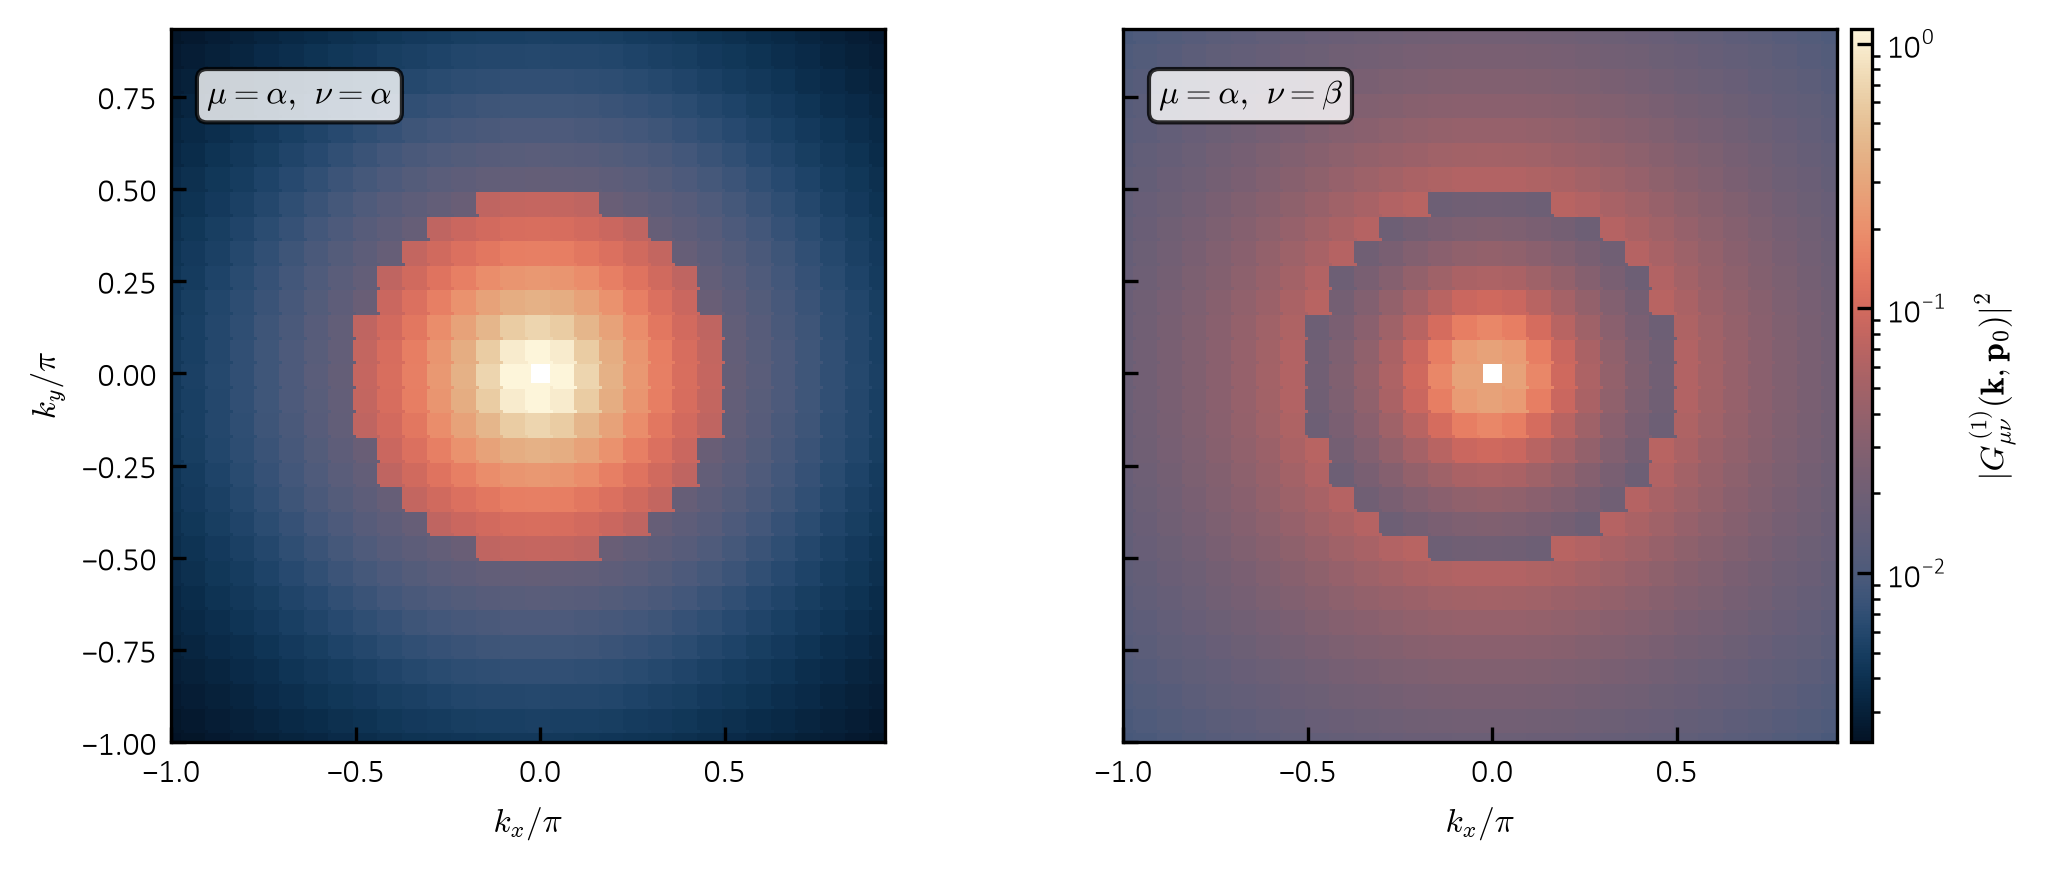

In [196]:
ib = 0     # bath shown; for disp=constant the baths differ only by w0
zb = np.abs(gm[ib, :, :, mu]) ** 2    # |G_{mu nu}(k, p0)|^2, shape (N, 2)
zp = zb[zb > 0.0]
norm = LogNorm(vmin=zp.min(), vmax=zp.max())

kx = np.unique(kg[:, 0]) / np.pi
ky = np.unique(kg[:, 1]) / np.pi
bl = (r"\alpha", r"\beta")

with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    for nu, a in enumerate(fg.ax):
        zz = np.ma.masked_equal(zb[:, nu].reshape(bd.shape).T, 0.0)
        im = color_map(a, kx, ky, zz, norm=norm)
        a.text(0.05, 0.93, rf"$\mu={bl[mu]},\ \nu={bl[nu]}$",
               transform=a.transAxes, ha="left", va="top",
               bbox=dict(boxstyle="round,pad=0.3", fc="white",
                         ec="black", alpha=0.8))
        format_ax(a, x=kx, xlabel=r"$k_x/\pi$", grid=False)
        a.set_aspect("equal")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")
    fg.colorbar(im, rf"$|G^{{({ib + 1})}}_{{\mu\nu}}(\mathbf{{k}},\mathbf{{p}}_0)|^2$",
                ax=fg.ax[-1], external=True)

In [197]:
pk = pb.pack(bs)
e = np.asarray(st.e)
de = e - e[mu, ip]
w = np.abs(de)
qm = np.linalg.norm(qk, axis=1)

om = [np.asarray(pb.omega_q(qm, c)) for c in bs]                  # omega_q^(b)
ls = [pb._line(jnp.asarray(w), jnp.asarray(o)[None, :], c.ew, pk)
      for c, o in zip(bs, om)]                                    # (sp, sl) per bath

nb = [np.asarray(pb._bose(jnp.asarray(w), c.t)) for c in bs]
fs = np.stack([np.where(de < 0.0, 1.0 + n, n) for n in nb])       # F_b, (bath, 2, N)
fb = fs.sum(axis=0)

lz = np.stack([np.array(s) for s, _ in ls])                       # L_b, (bath, 2, N)
lz[:, mu, ip] = np.nan
fb[mu, ip] = np.nan

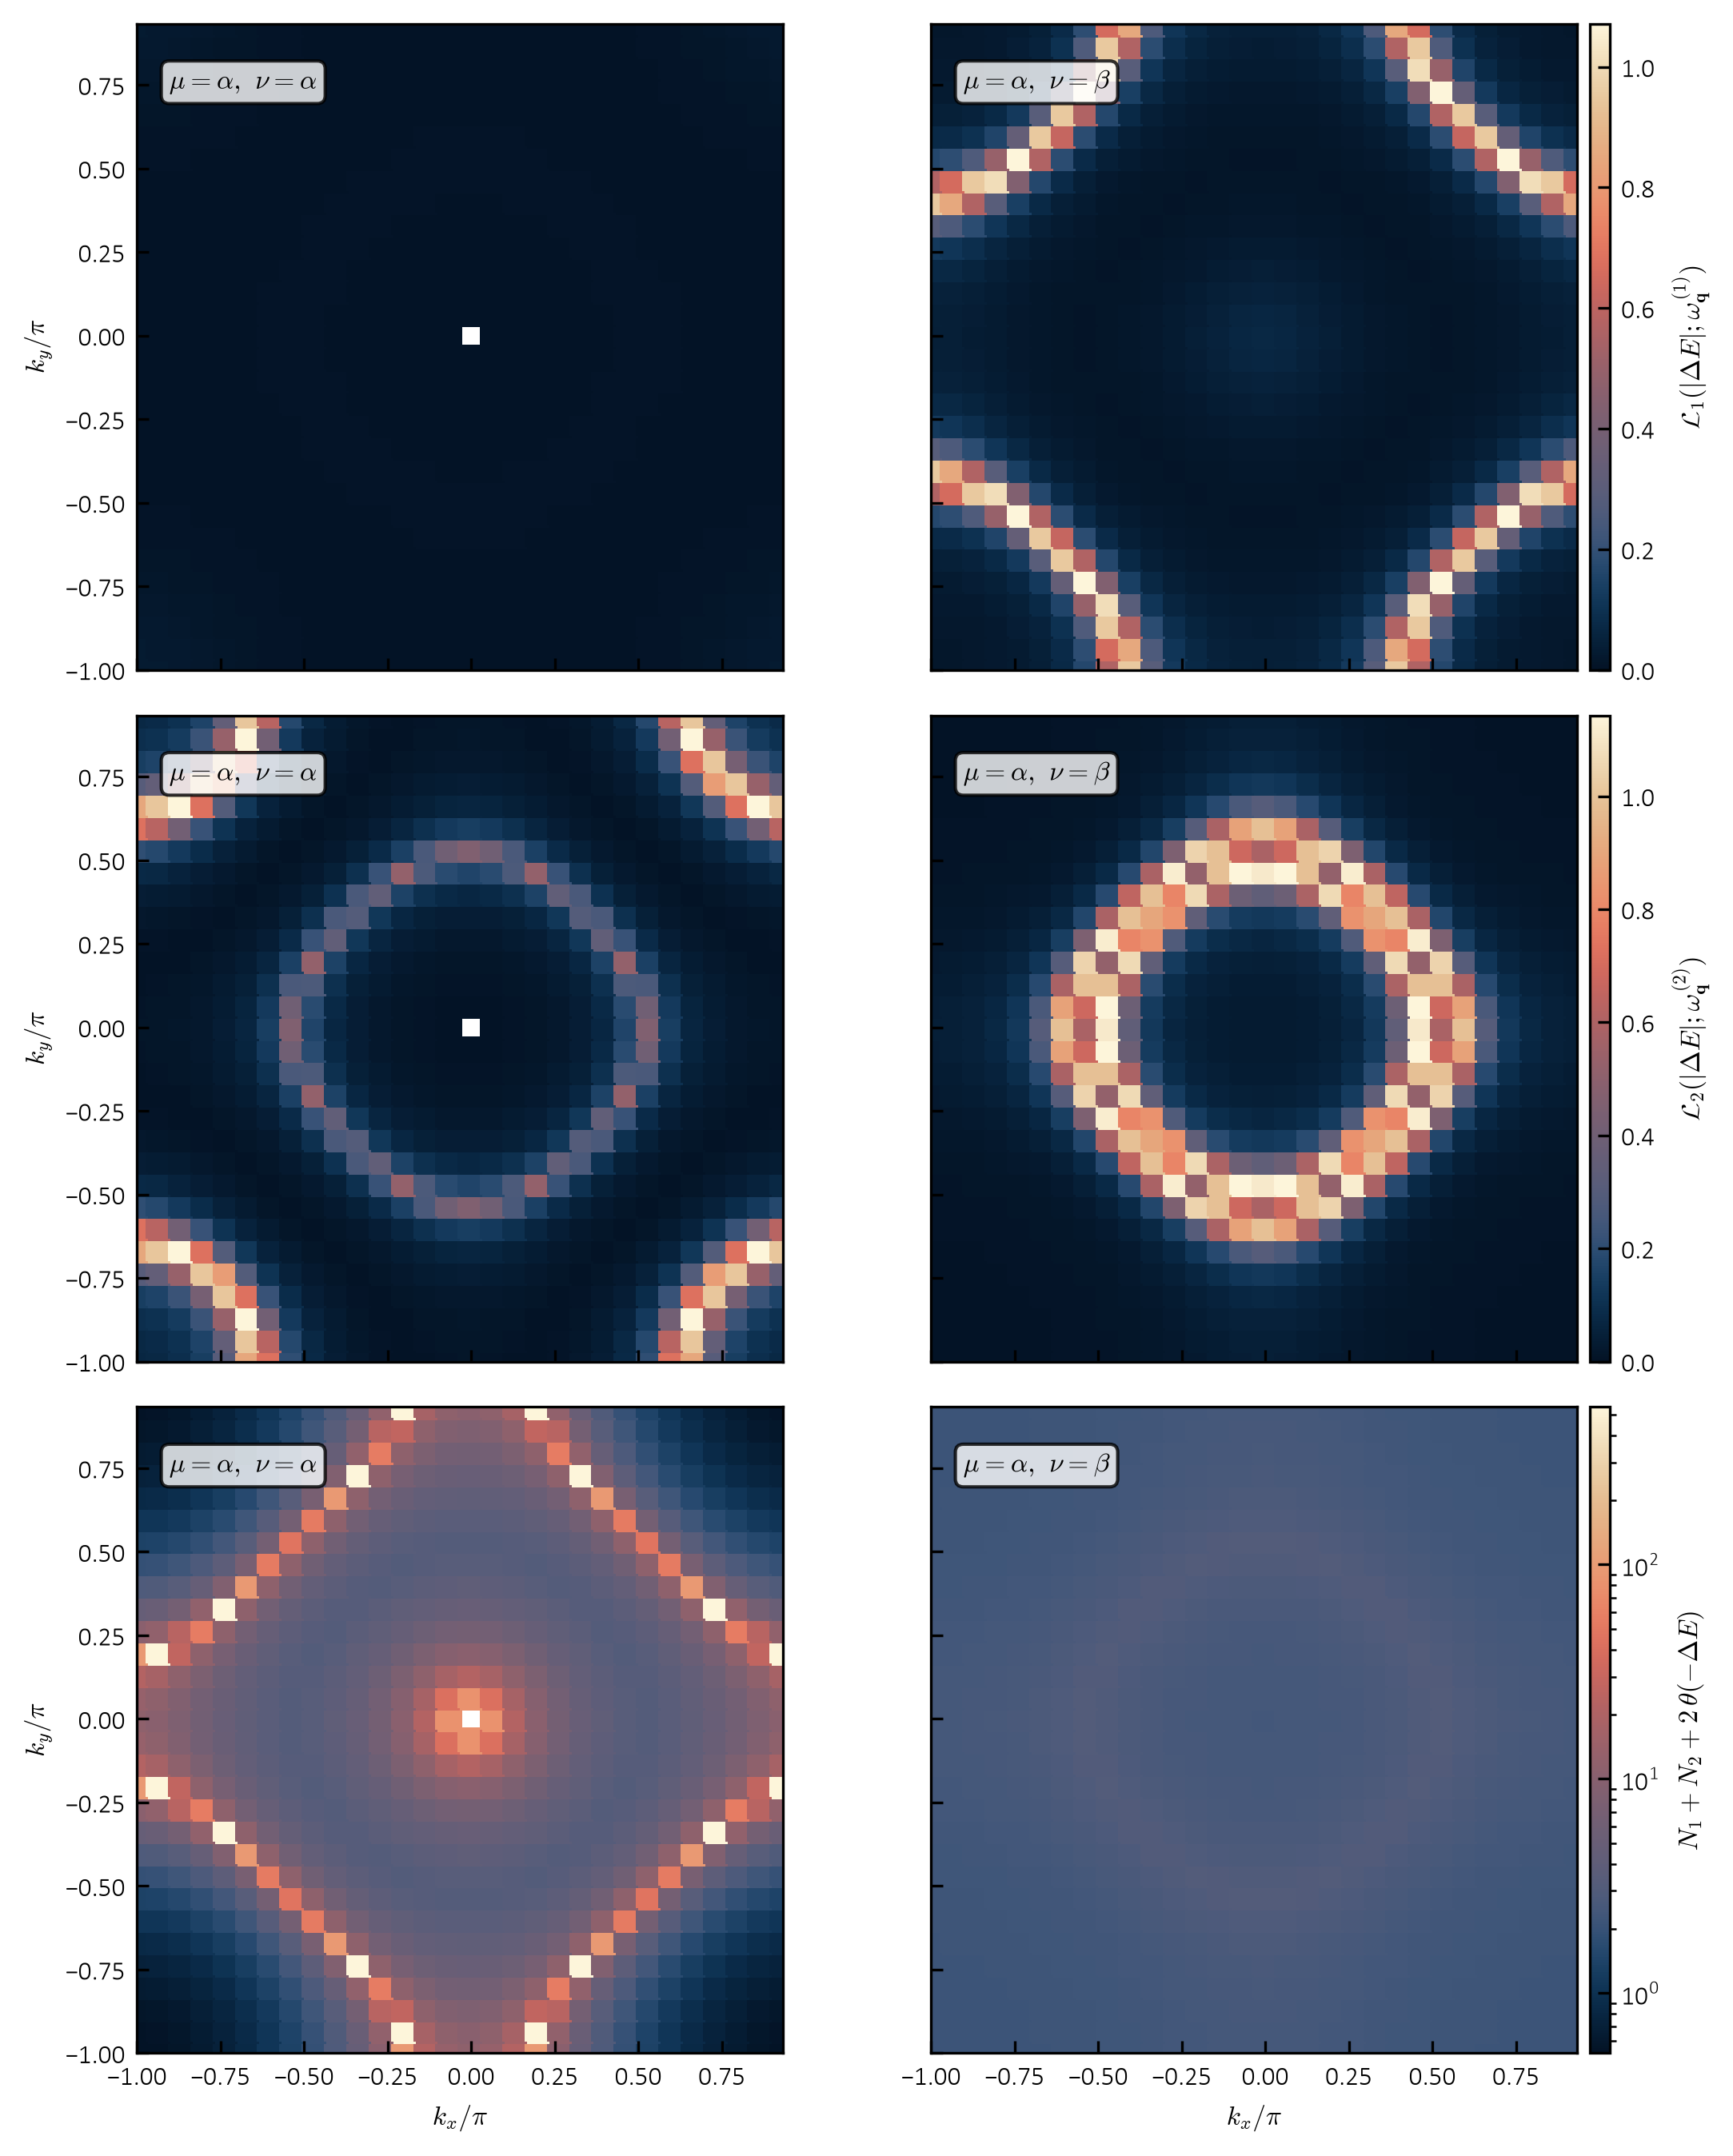

In [198]:
def lnorm(z, dr=1.0e-8):
    """Log norm over positive finite values, floored at dr * max."""
    zp = z[np.isfinite(z) & (z > 0.0)]
    return LogNorm(vmin=max(zp.min(), dr * zp.max()), vmax=zp.max())


def bz_pair(fg, ax, z, norm, lab):
    """Draw the nu = alpha, beta panels of a (2, N) field over the BZ."""
    for nu, a in enumerate(ax):
        zz = np.ma.masked_invalid(z[nu].reshape(bd.shape).T)
        im = color_map(a, kx, ky, zz, norm=norm)
        a.text(0.05, 0.93, rf"$\mu={bl[mu]},\ \nu={bl[nu]}$",
               transform=a.transAxes, ha="left", va="top",
               bbox=dict(boxstyle="round,pad=0.3", fc="white",
                         ec="black", alpha=0.8))
        format_ax(a, x=kx, grid=False)
        a.set_aspect("equal")
    fg.colorbar(im, lab, ax=ax[-1], external=True)


nr = len(bs) + 1
with pt.figure(shape=(nr, 2), h=0.85 * nr, w=2.0, sharex=True, sharey=True) as fg:
    for i in range(len(bs)):
        bz_pair(fg, fg.ax[i], lz[i], Normalize(0.0, np.nanmax(lz[i])),
                rf"$\mathcal{{L}}_{i + 1}(|\Delta E|;\omega^{{({i + 1})}}_\mathbf{{q}})$")
    bz_pair(fg, fg.ax[-1], fb, lnorm(fb), r"$N_1+N_2+2\,\theta(-\Delta E)$")
    for a in fg.ax[-1]:
        a.set_xlabel(r"$k_x/\pi$")
    for a in fg.ax[:, 0]:
        a.set_ylabel(r"$k_y/\pi$")

max rel. diff, factors vs source_rates: 3.46e-16


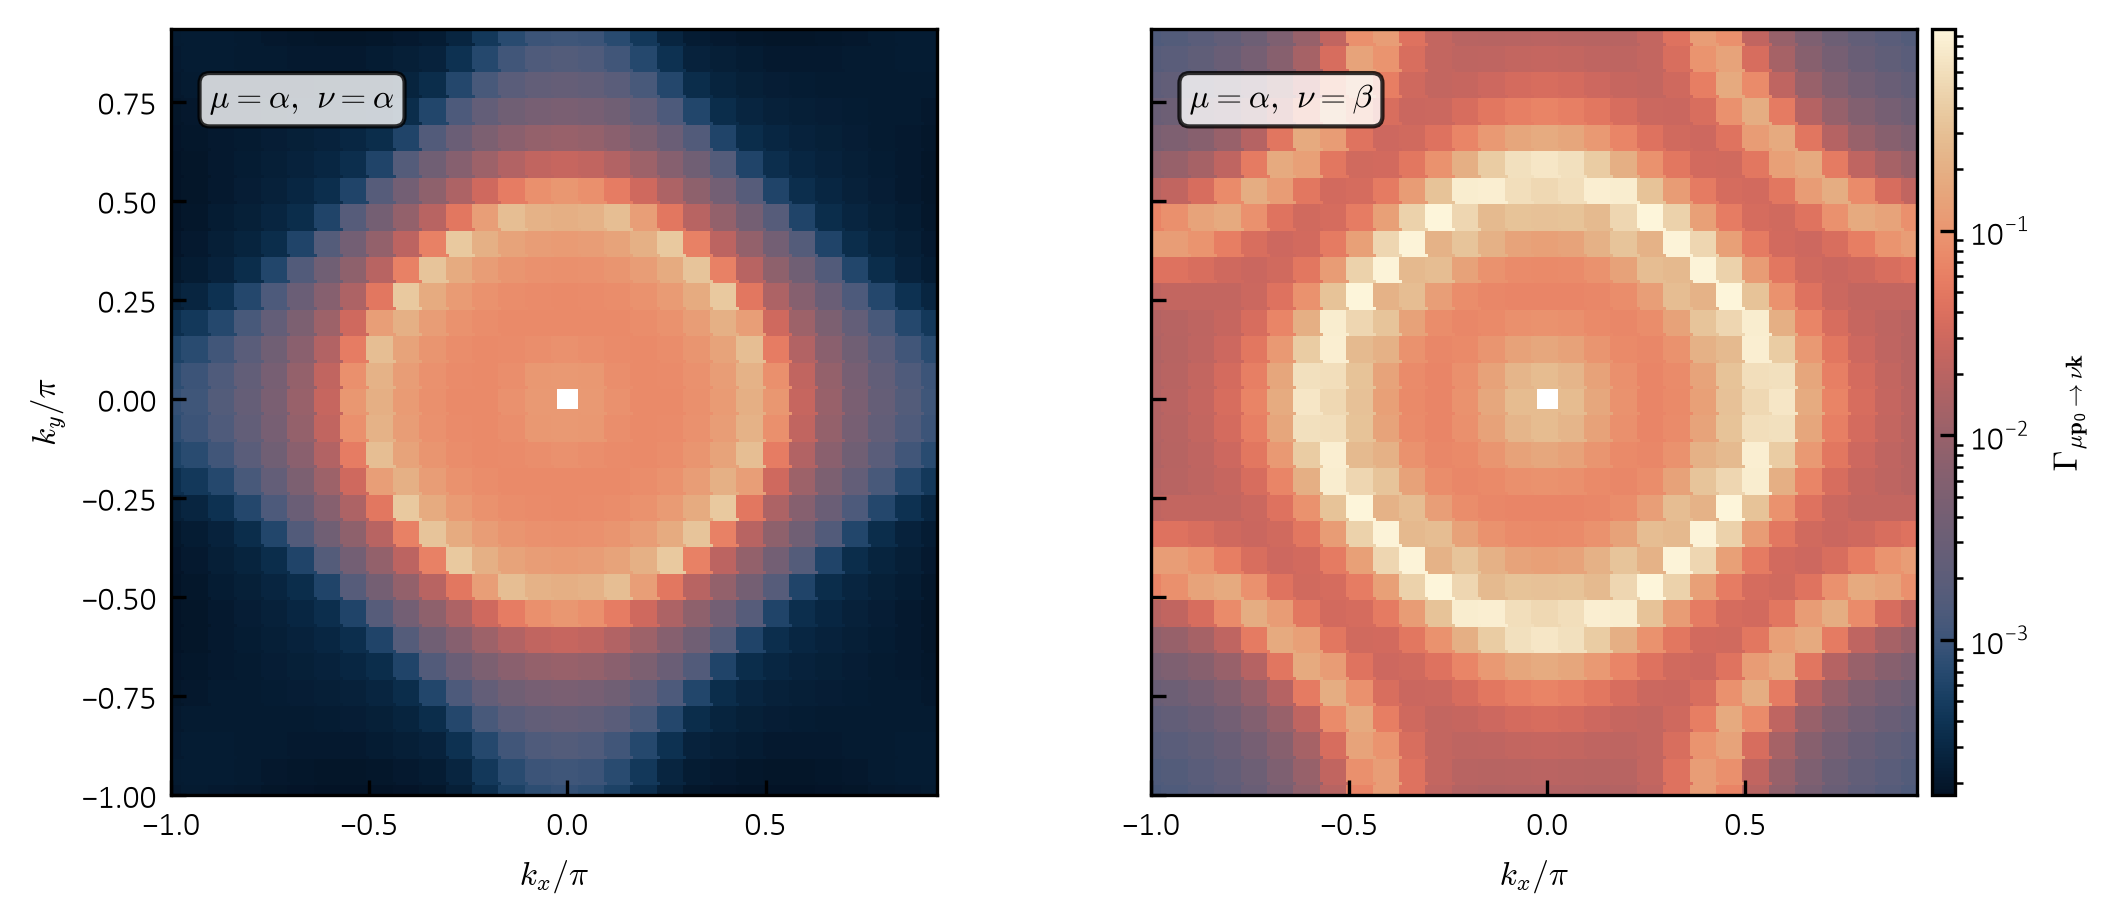

In [199]:
gr = np.asarray(pb.source_rates(st, bs, mu, ip))
g2 = 2.0 * np.pi * np.abs(gm[:, :, :, mu]).transpose(0, 2, 1) ** 2   # (bath, nu, N)

gb = []
for i, c in enumerate(bs):
    ab, em = pb._therm(*ls[i], jnp.asarray(w), c.t)
    gb.append(g2[i] * np.where(de < 0.0, em, ab))
gb = np.stack(gb)                       # Gamma per bath, (bath, 2, N)
gb[:, mu, ip] = 0.0
gc = gb.sum(axis=0)

er = np.max(np.abs(gc - gr)) / np.max(np.abs(gr))
print(f"max rel. diff, factors vs source_rates: {er:.2e}")

gp = gr.copy()
gp[mu, ip] = np.nan
with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax, gp, lnorm(gp),
            r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$")
    for a in fg.ax:
        a.set_xlabel(r"$k_x/\pi$")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")

In [200]:
ij, x, xt = k_path(bd)
sh = bd.shape
tl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]

epa = take_path(e, ij, sh)                 # E_{nu k} on the path ("ep" is taken)
wq = [take_path(o, ij, sh) for o in om]    # omega_q^(b) on the path
e0 = e[mu, ip]

ms = np.zeros_like(de, dtype=bool)         # self-term mask ("sf" is taken)
ms[mu, ip] = True


def on_path(z):
    """Take a (2, N) field onto the path, with the self term as NaN."""
    z = np.where(ms, np.nan, np.asarray(z, dtype=float))
    return take_path(z, ij, sh)


def cross(y, lv):
    """Path positions where y crosses lv (linear interpolation)."""
    d = y - lv
    i = np.where(np.sign(d[:-1]) * np.sign(d[1:]) < 0)[0]
    return x[i] - d[i] * (x[i + 1] - x[i]) / (d[i + 1] - d[i])


yg, yl, yf, yb = (np.stack([on_path(z) for z in zz]) for zz in (g2, lz, fs, gb))
yr = on_path(gr)                           # total Gamma, (2, L)

/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:509: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout(rect=self.rect)


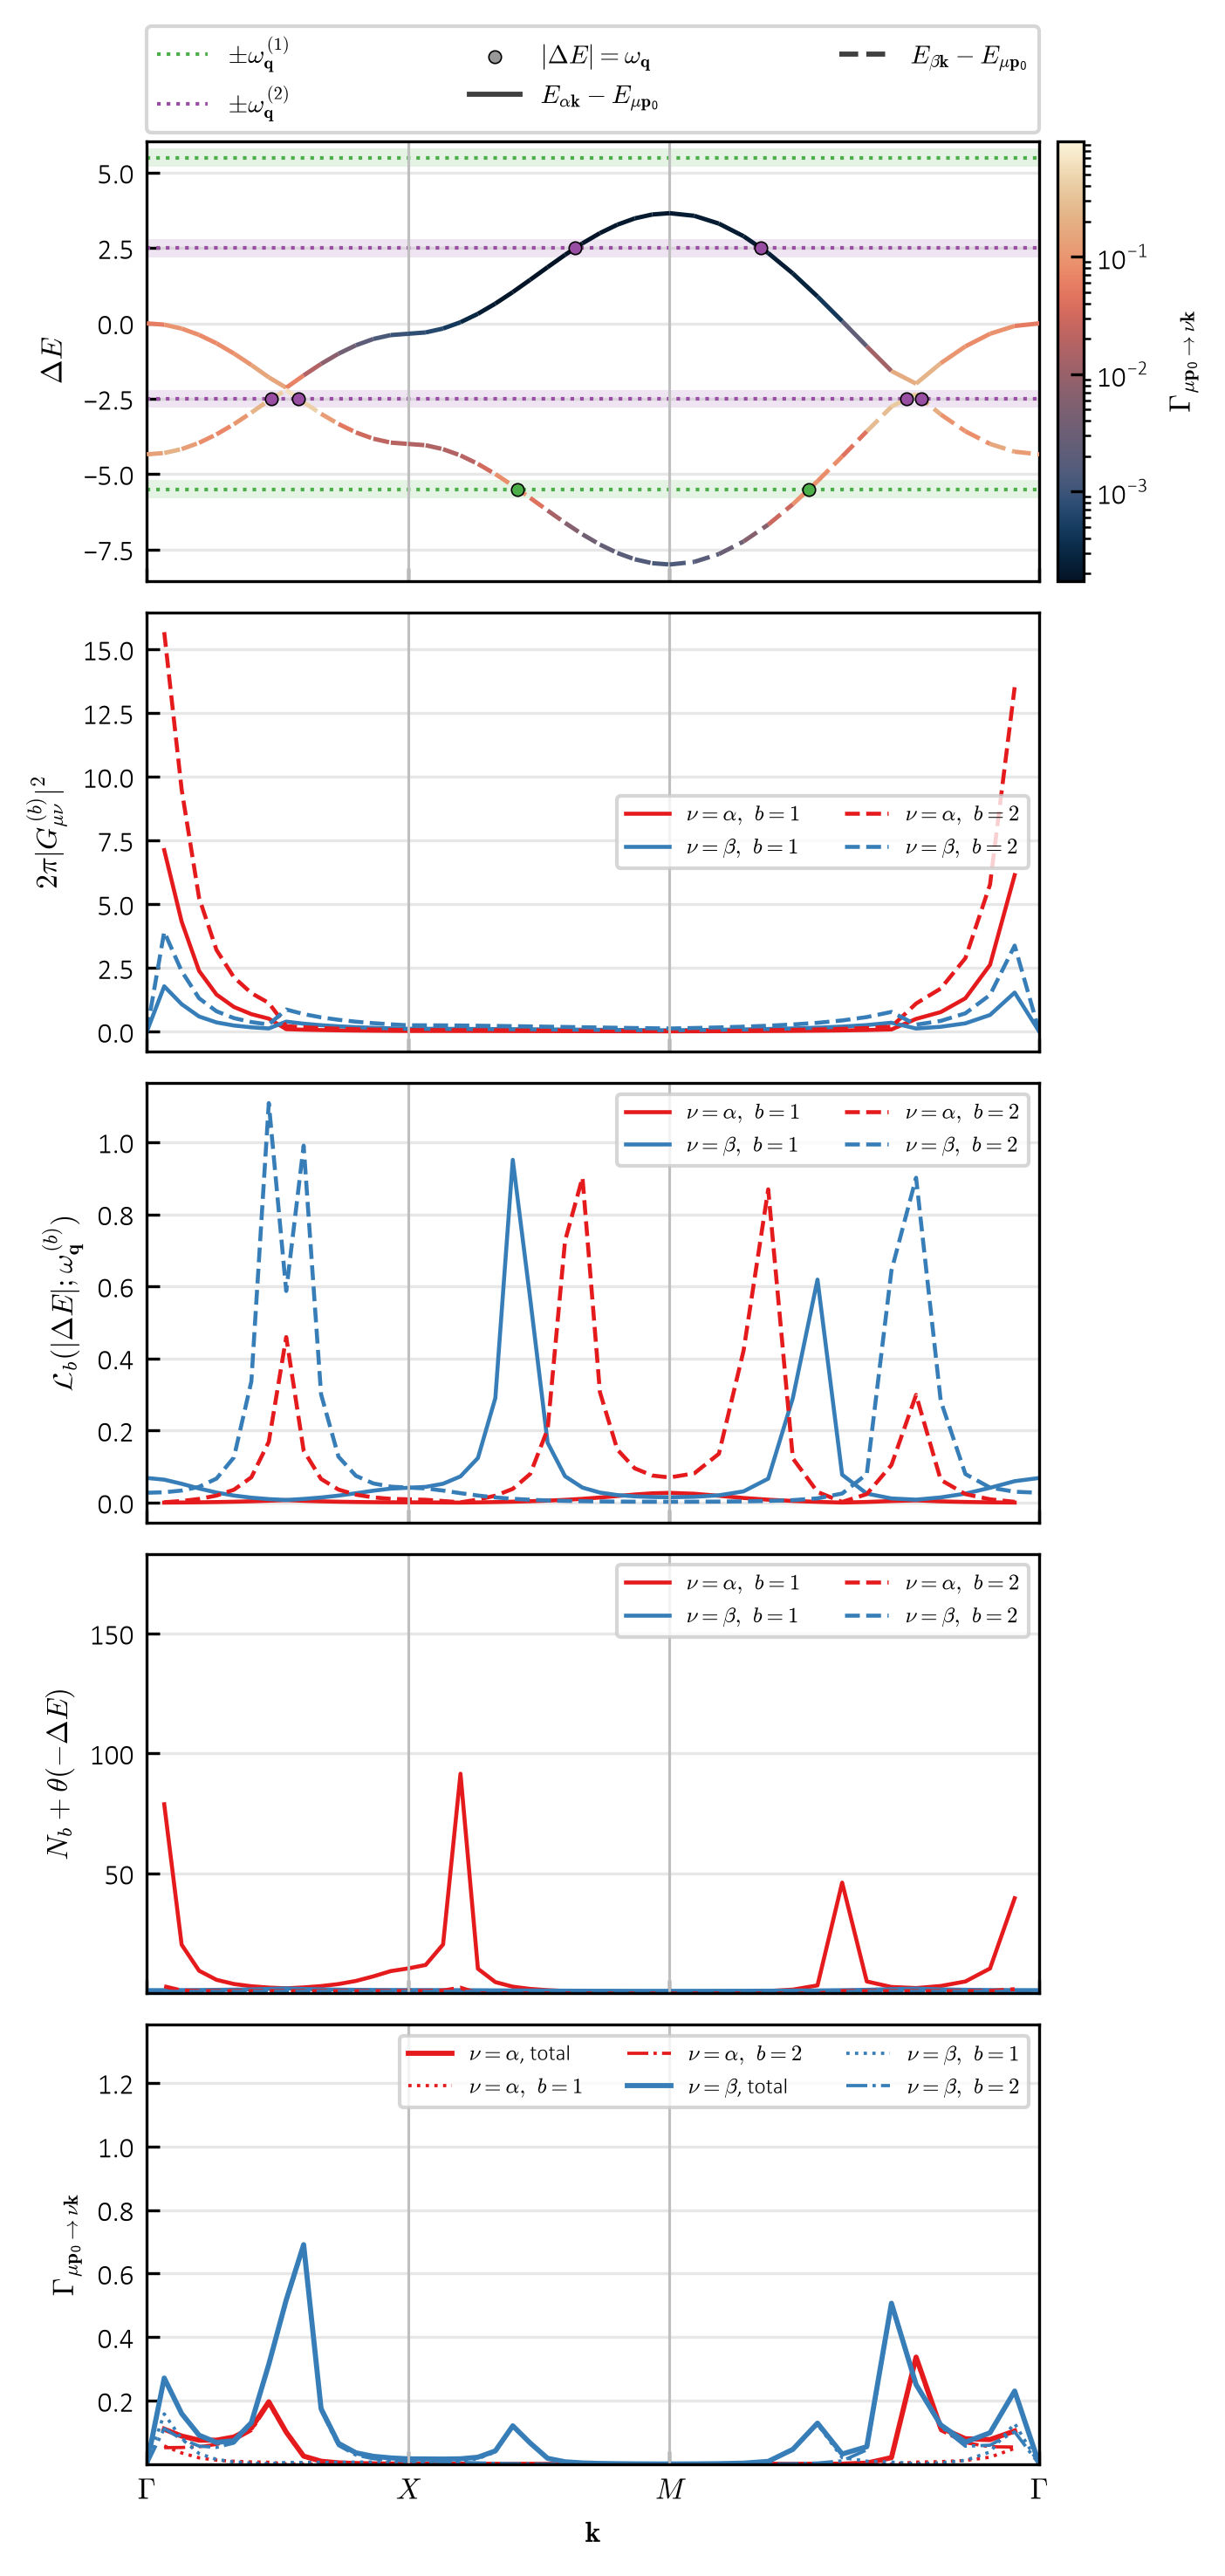

In [201]:
bcl = (SET1_LIST[2], SET1_LIST[3])     # bath colours in panel 1
bst = ("-", "--")                      # bath line styles, panels 2-4
pst = (":", "-.")                      # bath line styles, panel 5
dea = epa - e0                         # Delta E on the path, (2, L)

rows = (
    (yg, r"$2\pi|G^{(b)}_{\mu\nu}|^2$", False),
    (yl, r"$\mathcal{L}_b(|\Delta E|;\omega^{(b)}_\mathbf{q})$", False),
    (yf, r"$N_b+\theta(-\Delta E)$", True),
)
cn = lnorm(gr)

with pt.figure(shape=(5, 1), h=3.0, w=1.2, sharex=True) as fg:
    a = fg.ax[0]
    for ib, c in enumerate(bs):
        for s in (1.0, -1.0):
            lv = s * wq[ib]
            a.fill_between(x, lv - c.ew, lv + c.ew,
                           color=bcl[ib], alpha=0.15, lw=0)
            a.plot(x, lv, color=bcl[ib], ls=":", lw=1.0,
                   label=rf"$\pm\omega^{{({ib + 1})}}_\mathbf{{q}}$" if s > 0 else None)
            for nu in range(2):
                xc = cross(dea[nu], lv)
                a.scatter(xc, np.interp(xc, x, lv), color=bcl[ib], s=12,
                          edgecolors="k", linewidths=0.4, zorder=6)
    a.scatter([], [], color="0.6", s=12, edgecolors="k", linewidths=0.4,
              label=r"$|\Delta E|=\omega_\mathbf{q}$")
    for nu, sty in enumerate(("-", "--")):
        cv = np.nan_to_num(yr[nu], nan=cn.vmin)
        lc = color_line(a, x, dea[nu], cv, np.full_like(x, 0.4),
                        cmaps.lipari, cn, ls=sty,
                        label=rf"$E_{{{bl[nu]}\mathbf{{k}}}} - E_{{\mu\mathbf{{p}}_0}}$")
    yy = np.r_[dea.ravel(), np.concatenate(wq), -np.concatenate(wq)]
    dy = 0.04 * (np.nanmax(yy) - np.nanmin(yy))
    format_ax(a, x=x, ylabel=r"$\Delta E$",
              ylim=(np.nanmin(yy) - dy, np.nanmax(yy) + dy), xticks=xt)
    add_legend(a, top=True, ncol=3, fontsize=7)
    fg.colorbar(lc, r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$",
                ax=a, external=True)

    for a, (y, lab, lg) in zip(fg.ax[1:4], rows):
        for ib in range(len(bs)):
            for nu in range(2):
                a.plot(x, y[ib, nu], color=SET1_LIST[nu], ls=bst[ib], lw=1.1,
                       label=rf"$\nu={bl[nu]},\ b={ib + 1}$")
        if lg:
            # a.set_yscale("log")
            a.set_ylim(1.0e-8 * np.nanmax(y), 2.0 * np.nanmax(y))
        format_ax(a, x=x, ylabel=lab, xticks=xt)
        add_legend(a, ncol=2, fontsize=6)

    a = fg.ax[4]
    for nu in range(2):
        a.plot(x, yr[nu], color=SET1_LIST[nu], lw=1.4,
               label=rf"$\nu={bl[nu]}$, total")
        for ib in range(len(bs)):
            a.plot(x, yb[ib, nu], color=SET1_LIST[nu], ls=pst[ib], lw=0.9,
                   label=rf"$\nu={bl[nu]},\ b={ib + 1}$")
    # a.set_yscale("log")
    a.set_ylim(1.0e-8 * np.nanmax(yr), 2.0 * np.nanmax(yr))
    format_ax(a, x=x, ylabel=r"$\Gamma_{\mu\mathbf{p}_0\to\nu\mathbf{k}}$",
              xticks=xt)
    add_legend(a, ncol=3, fontsize=6)

    for a in fg.ax:
        a.axvline(xt[1], color="0.75", lw=0.7)
        a.axvline(xt[2], color="0.75", lw=0.7)
    fg.ax[-1].set_xticklabels(tl)
    fg.ax[-1].set_xlabel(r"$\mathbf{k}$")
    fg.layout((0, 0, 1, 0.95))

In [202]:
ef = e.reshape(-1)                        # flat (alpha k, beta k) energies

for c in bs:
    r = np.asarray(pb.rates(st, pb.pack((c,))))    # R[dest, src], one bath
    ok = (r > 1e-12 * r.max()) & (r.T > 1e-12 * r.max())
    lr = np.log(r[ok] / r.T[ok])                   # log(R_ij / R_ji)
    ex = -(ef[:, None] - ef[None, :])[ok] / c.t    # -(E_i - E_j) / T
    print(c.name, "max detailed-balance error:", np.max(np.abs(lr - ex)))

bath_1 max detailed-balance error: 3.552713678800501e-15
bath_2 max detailed-balance error: 3.885780586188048e-15


In [203]:
import dataclasses
import EI.eff_T as et

et.ej = ej      # route eff_T through ei_jax_2 in this kernel

mc = 0.0        # chemical potential; ei_jax_2 energies already carry -V/2
ep = {
    "dt": 0.1, "mix": [0.15, 0.15], "tol": 1.0e-5,
    "nmax": 20000, "chk": 10, "mf": False, "prog": True,
    "mode": "block", "block": 512,
}


sf = solve_teff(bd, p, bs, so, t1, t2, mc, op, ep)
sf = dataclasses.replace(sf, st=so.st)   # same d, m since mf=False

logger.info("Delta = %.6f, m = %.6f", so.d, so.m)
logger.info("T_eff/T_c = %.6f, power = %.3e, ok = %s",
            sf.t / tc, sf.power, sf.ok)

Effective temperature:   0%|          | 0/20000 [00:00<?, ?it/s]

[20:43:05] [INFO    ] Delta = -0.000000, m = -0.376189
[20:43:05] [INFO    ] T_eff/T_c = 2.147028, power = -7.044e-06, ok = True


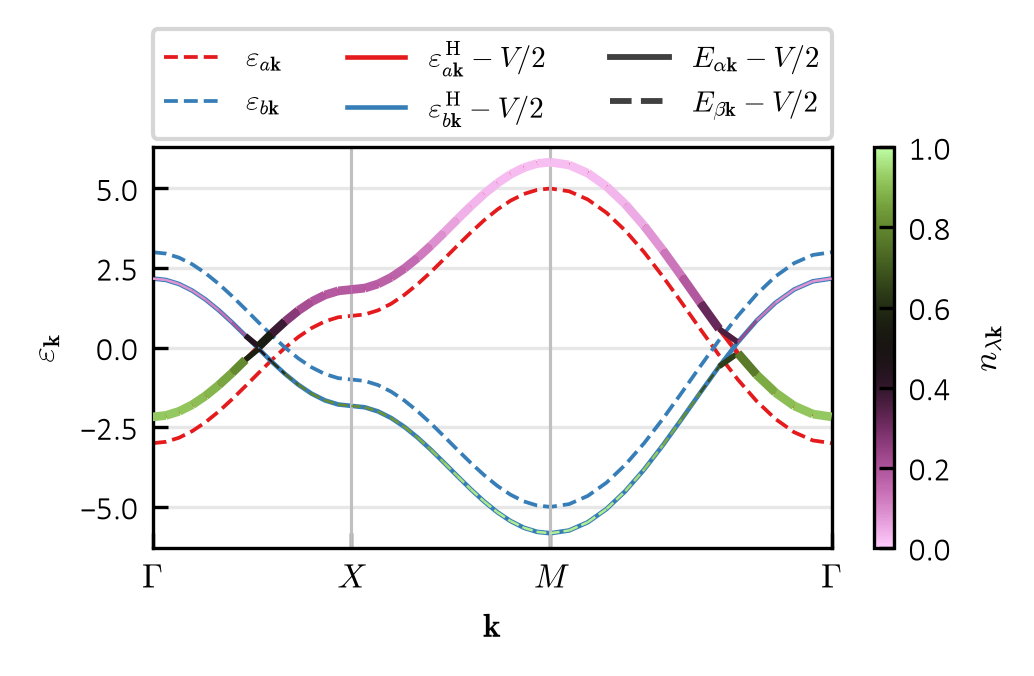

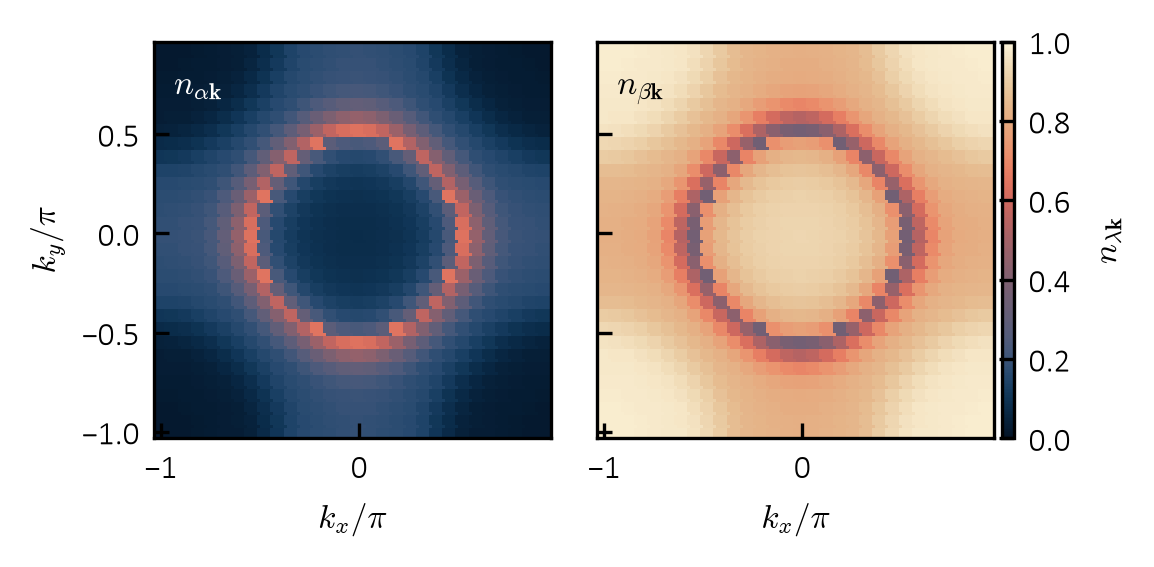

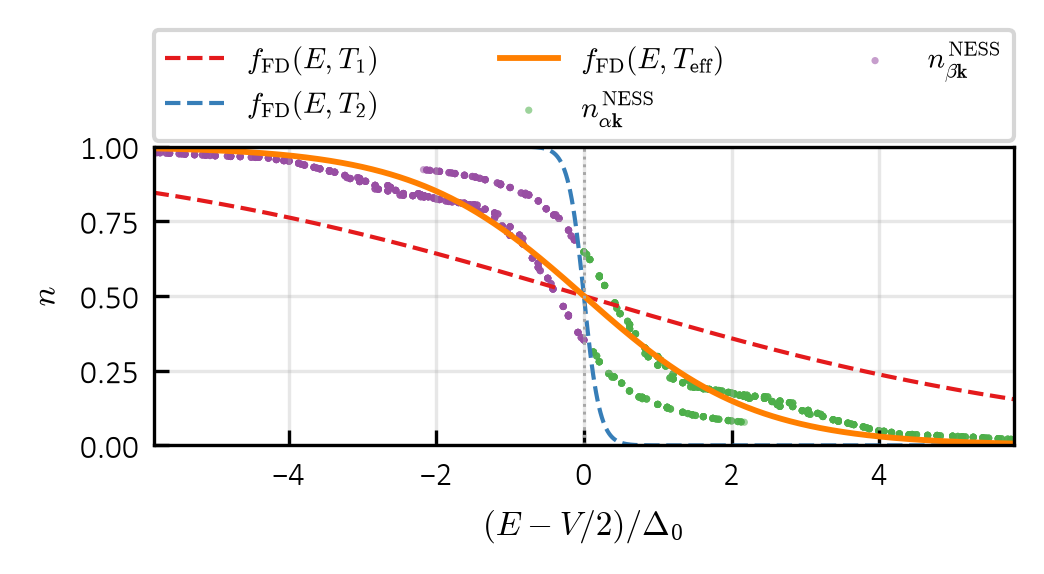

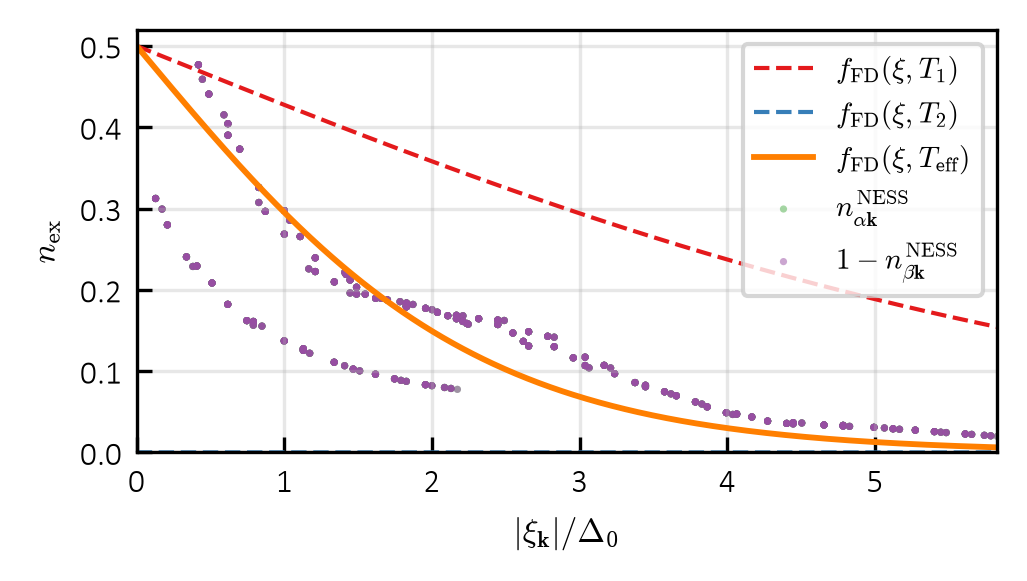

In [204]:
plot_dispersion(pt, bd, so, mc)                 # bands on Gamma-X-M, coloured by n
plot_bz(pt, bd, so)                             # 2D n_alpha, n_beta
plot_energy(pt, so, sf, t1, t2, mc, d0)         # n vs E against FD at T1, T2, T_eff
plot_xi(pt, bd, p, eq, so, sf, t1, t2, d0)      # n vs |xi| against FD at T1, T2, T_eff

In [205]:
w0 = bs[0].w0
nm = 0.5 * sum(1.0 / np.expm1(w0 / c.t) for c in bs)   # N_bar(omega_0)
ts = w0 / np.log1p(1.0 / nm)                           # T* from the ratio
print(f"T*/Tc = {ts / tc:.4f},  T_eff/Tc = {sf.t / tc:.4f},  Delta = {so.d:.2e}")

T*/Tc = 4.6858,  T_eff/Tc = 2.1470,  Delta = -6.48e-38


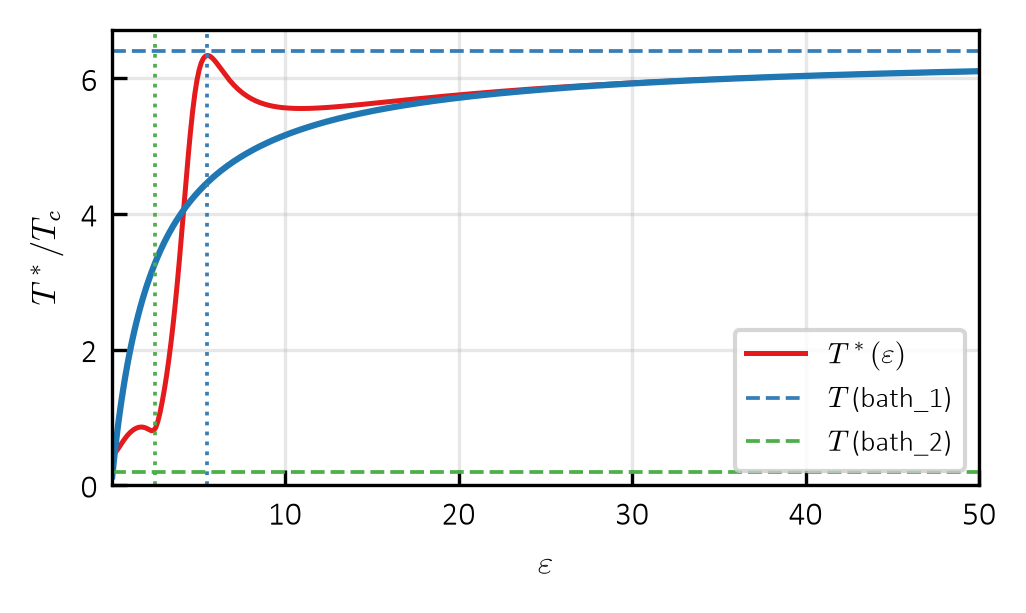

In [217]:
eg = np.linspace(0.05, 50.0, 400)          # energy transfer grid
dn, up = 0.0, 0.0
for c in bs:
    a = np.asarray(pb._spec_e(jnp.asarray(eg), c.w0, c.ew)) * c.amp / c.w0
    n = np.asarray(pb._bose(jnp.asarray(eg), c.t))
    dn, up = dn + a * (1.0 + n), up + a * n
tsf = eg / np.log(dn / up)                # T*(eps)

with pt.figure(h=0.6) as fg:
    a = fg.ax
    a.plot(eg, tsf / tc, color=SET1_LIST[0], lw=1.2, label=r"$T^*(\varepsilon)$")
    a.plot(eg, t1n / (1 + t1n * np.log(1 + bs[1].w0 / bs[0].w0) / eg))
    for c, cl in zip(bs, SET1_LIST[1:3]):
        a.axhline(c.t / tc, color=cl, ls="--", lw=0.9, label=rf"$T$ ({c.name})")
        a.axvline(c.w0, color=cl, ls=":", lw=0.9)
    format_ax(a, x=eg, xlabel=r"$\varepsilon$", ylabel=r"$T^*/T_c$")
    add_legend(a, ncol=1, fontsize=7)
    a.set_ylim(0, t1n*1.05)

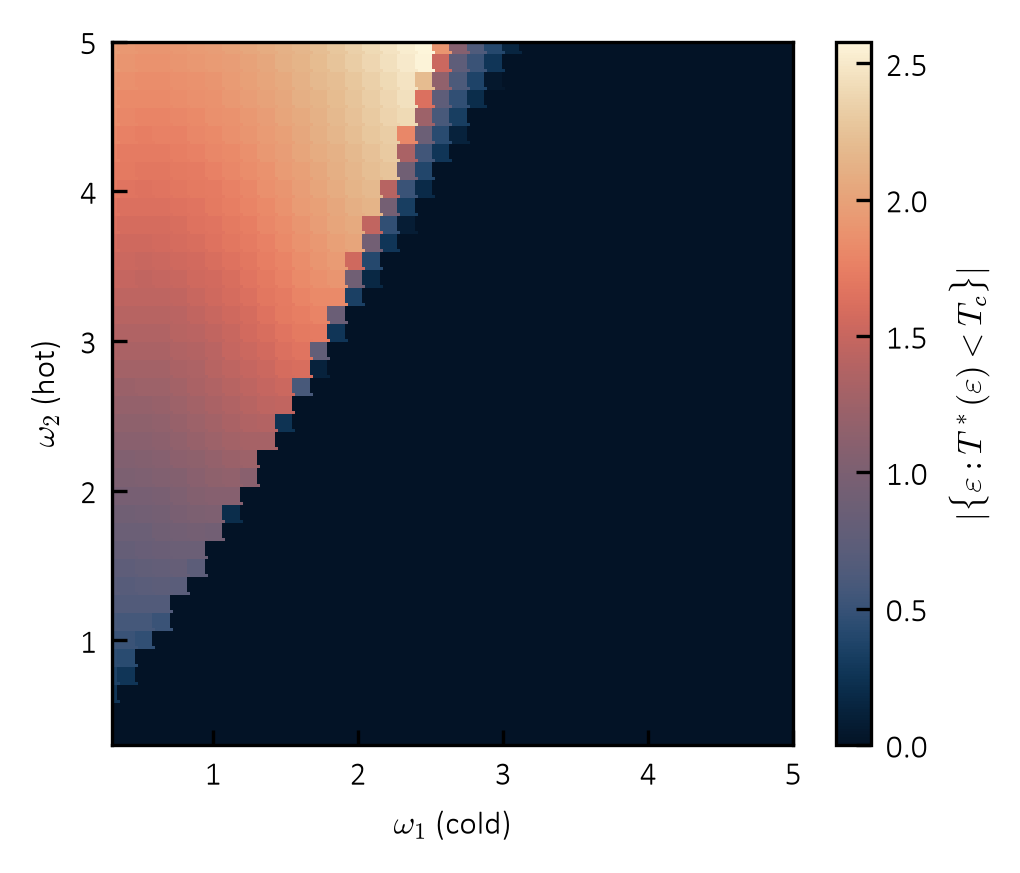

In [218]:
def nbar(eg, bath):
    """Weighted occupation N_bar(eps); bath = [(w0, ew, amp, t), ...]."""
    eg = jnp.asarray(eg)
    a = [pb._spec_e(eg, w0, ew) * amp / w0 for w0, ew, amp, _ in bath]
    n = [pb._bose(eg, t) for *_, t in bath]
    return np.asarray(sum(x * y for x, y in zip(a, n)) / sum(a))


def tstar(eg, bath):
    """T*(eps) = eps / ln(1 + 1/N_bar)."""
    with np.errstate(divide="ignore"):
        return eg / np.log1p(1.0 / nbar(eg, bath))


eg = np.linspace(0.05, 8.0, 400)
wa = np.linspace(0.3, 5.0, 40)              # omega grid for both baths
ew, amp = bs[0].ew, bs[0].amp
tlo, thi = 0.2 * tc, 6.4 * tc               # cold, hot

wd = np.empty((wa.size, wa.size))           # rows omega_2 (hot), cols omega_1 (cold)
for i, w2 in enumerate(wa):
    for j, w1 in enumerate(wa):
        ts = tstar(eg, [(w1, ew, amp, tlo), (w2, ew, amp, thi)])
        wd[i, j] = np.trapezoid((ts < tc).astype(float), eg)

with pt.figure(h=0.85) as fg:
    im = color_map(fg.ax, wa, wa, wd)
    format_ax(fg.ax, x=wa, xlabel=r"$\omega_1$ (cold)", ylabel=r"$\omega_2$ (hot)", grid=False)
    fg.colorbar(im, r"$|\{\varepsilon : T^*(\varepsilon) < T_c\}|$", ax=fg.ax)

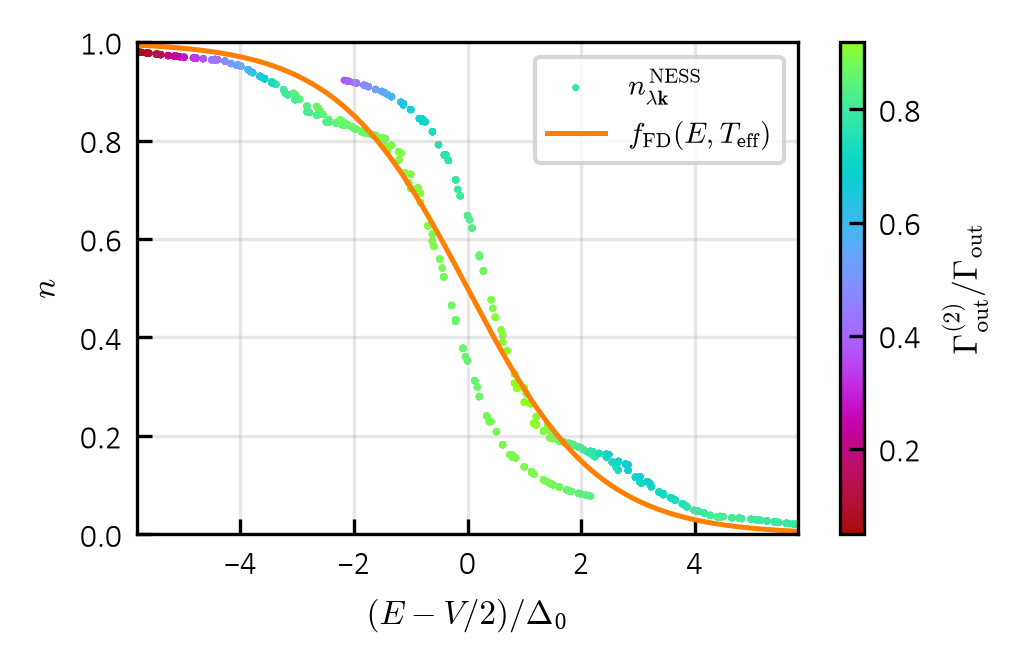

In [219]:
ef = np.asarray(st.e).reshape(-1)                       # (alpha k, beta k) energies
ro = [np.asarray(pb.rates(st, pb.pack((c,)))).sum(axis=0) for c in bs]
hf = ro[1] / (ro[0] + ro[1])                            # hot share of out-scattering
nn = np.asarray(so.n).reshape(-1)
xs = np.linspace(ef.min(), ef.max(), 400) / d0

with pt.figure(h=0.65) as fg:
    a = fg.ax
    im = a.scatter(ef / d0, nn, c=hf, s=3, cmap=cmaps.neon,
                   edgecolors="none", label=r"$n_{\lambda\mathbf{k}}^{\mathrm{NESS}}$")
    a.plot(xs, 1.0 / (np.exp(sf.beta * xs * d0) + 1.0), color=SET1_LIST[4],
           lw=1.2, label=r"$f_{\mathrm{FD}}(E,T_{\mathrm{eff}})$")
    format_ax(a, x=xs, xlabel=r"$(E-V/2)/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)
    fg.colorbar(im, r"$\Gamma^{(2)}_{\mathrm{out}}/\Gamma_{\mathrm{out}}$", ax=a)

In [220]:
# from phase_map_plots import scan_maps_ph

# skm = {**sk, "prog": False}
# zph = scan_maps_ph(bd, p, eq, op, t1a, d0, m0, skm, ov=ov)

# nok = int(np.count_nonzero(~zph["converged"]))
# logger.info("Nonconverged points = %d, max error = %.3e",
#             nok, np.nanmax(zph["error"]))

# zm = {q: np.where(zph["converged"], v, np.nan) if v.dtype.kind == "f" else v
#       for q, v in zph.items()}          # hide nonconverged points


In [221]:

# plot_maps(pt, tn, zph, d0)              # Delta, G^H(Gamma), G^diag(Gamma), G_ind^diag, m
# plot_cmap(tn, tn, zph["diag_min"] / d0, r"$G^{\mathrm{diag}}_{\min}/\Delta_0$",
#           cmap=cmaps.batlow, pt=pt)
# plot_cmap(tn, tn, zph["hartree_ind"] / d0, r"$G^{\mathrm{H}}_{\mathrm{ind}}/\Delta_0$",
#           cmap=cmaps.bubblegum, pt=pt)

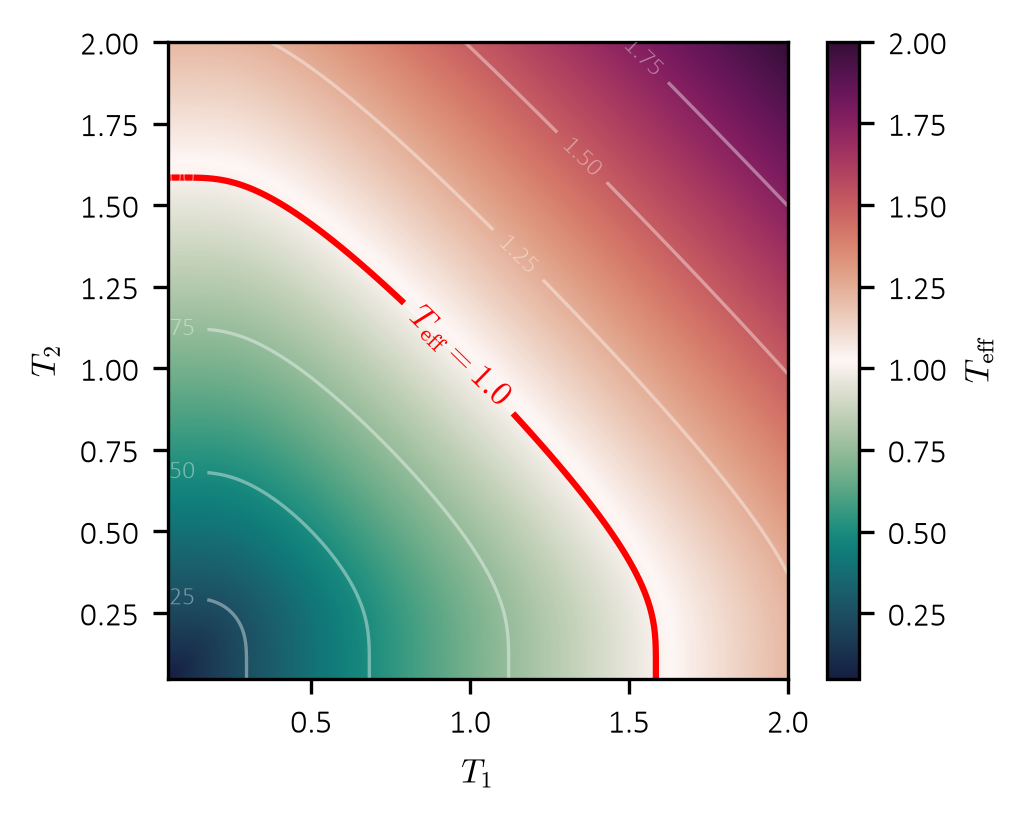

In [222]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define parameter omega_0
omega_0 = 1.1
# 2. Define the Bose-Einstein distribution function
def bose_distribution(omega, T):
    # Avoid division by zero at T = 0
    with np.errstate(divide='ignore', invalid='ignore'):
        n = 1.0 / (np.exp(omega / T) - 1.0)
    return n

# 3. Define T_eff function
def T_eff(T1, T2, omega):
    N1 = bose_distribution(omega, T1)
    N2 = bose_distribution(omega, T2)
    
    # Calculate effective temperature formula
    arg = 1.0 + 2.0 / (N1 + N2)
    return omega / np.log(arg)

T_range = np.linspace(0.05, 2.0, 1000)
T1, T2 = np.meshgrid(T_range, T_range)

Z = T_eff(T1, T2, omega_0)

plt.figure(figsize=(3.47412, 0.8 * 3.47412))

# Plot colormap (heatmap)
pcm = plt.pcolormesh(T1, T2, Z, cmap=cmaps.curl, shading='auto')
cbar = plt.colorbar(pcm, label=r'$T_{\mathrm{eff}}$')

# Add contour lines for general reference
contours = plt.contour(T1, T2, Z, levels=8, colors='white', alpha=0.4, linewidths=0.8)
plt.clabel(contours, inline=True, fontsize=6, fmt='%.2f')

# Highlight specific T_eff = 1 line
target_contour = plt.contour(T1, T2, Z, levels=[1.0], colors='red', linewidths=1.5, linestyles='-')
plt.clabel(target_contour, inline=True, fontsize=8, fmt=r'$T_{\mathrm{eff}} = 1.0$')

# Axis labels and styling
plt.xlabel(r'$T_1$')
plt.ylabel(r'$T_2$')

plt.tight_layout()
plt.show()

T2:   0%|                         0/20 [00:00<?, ?it/s]

T1:   0%|                         0/20 [00:00<?, ?it/s]

T1: |                         0/0 [00:00<?, ?it/s]

T1:   0%|                         0/20 [00:00<?, ?it/s]

T1: |                         0/0 [00:00<?, ?it/s]

...

T1:   0%|                         0/18 [00:00<?, ?it/s]

T1:   0%|                         0/2 [00:00<?, ?it/s]

T1:   0%|                         0/18 [00:00<?, ?it/s]

T1:   0%|                         0/2 [00:00<?, ?it/s]

Maps:   0%|                         0/7 [00:00<?, ?it/s]

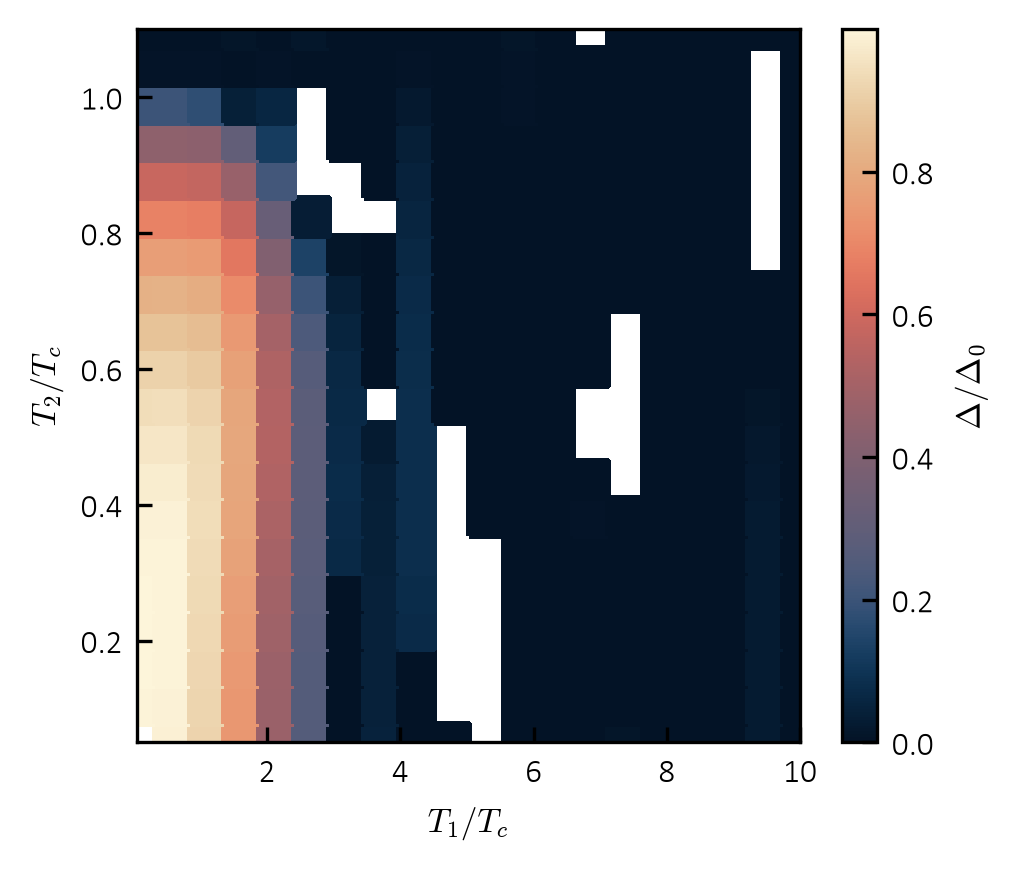

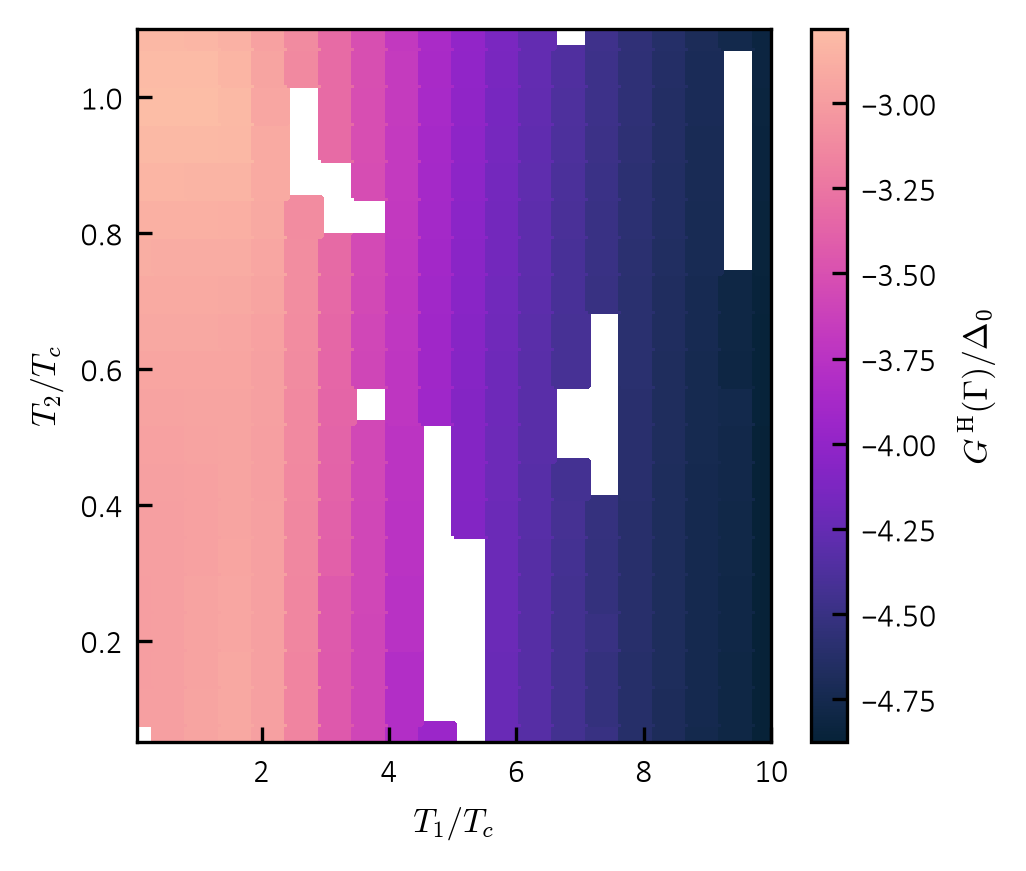

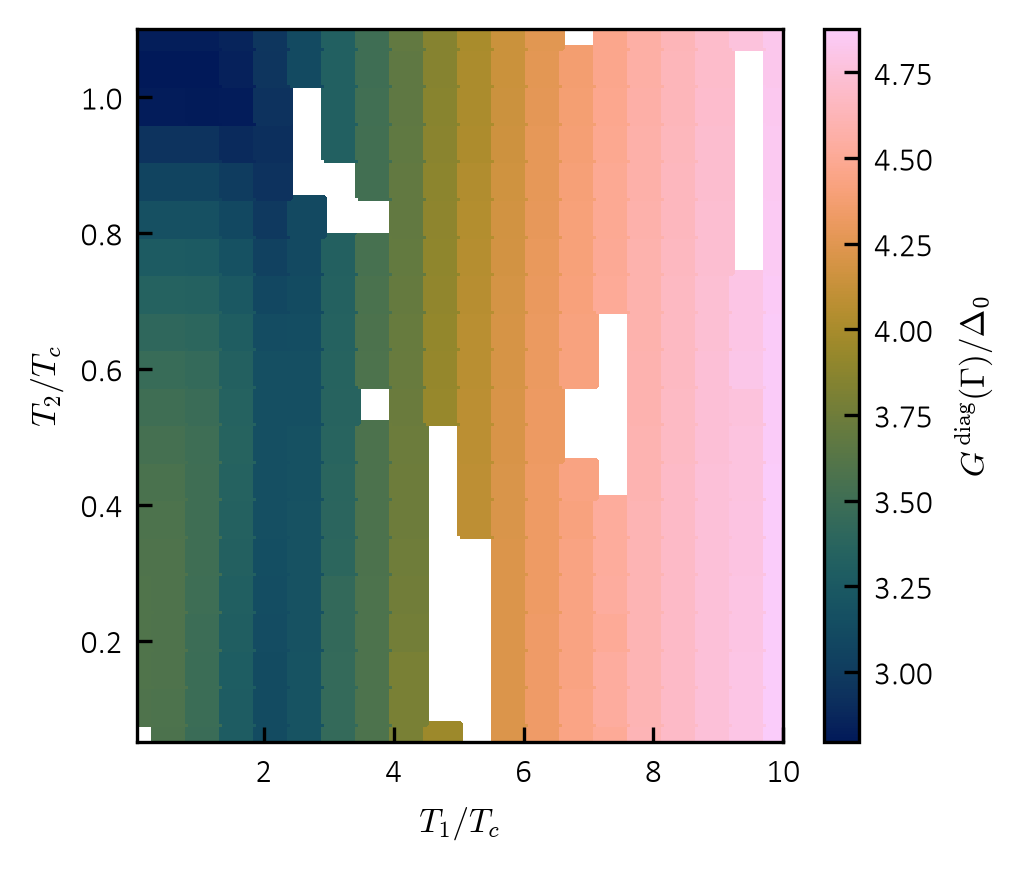

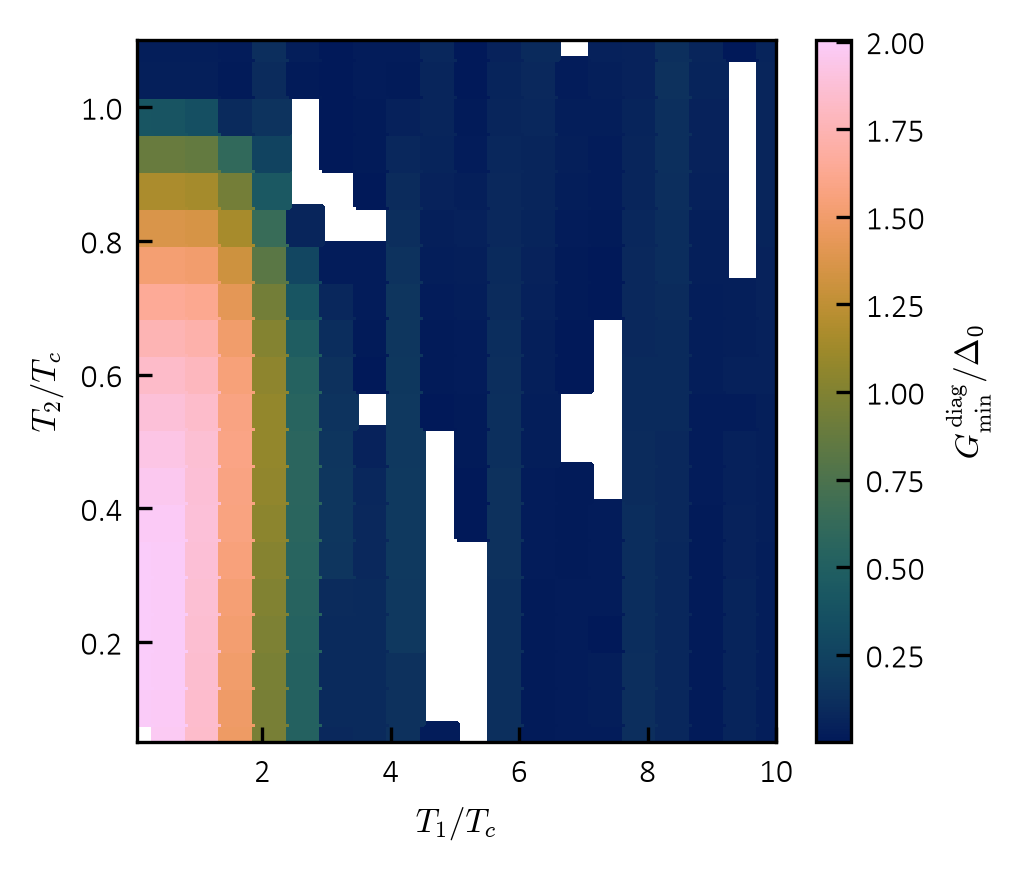

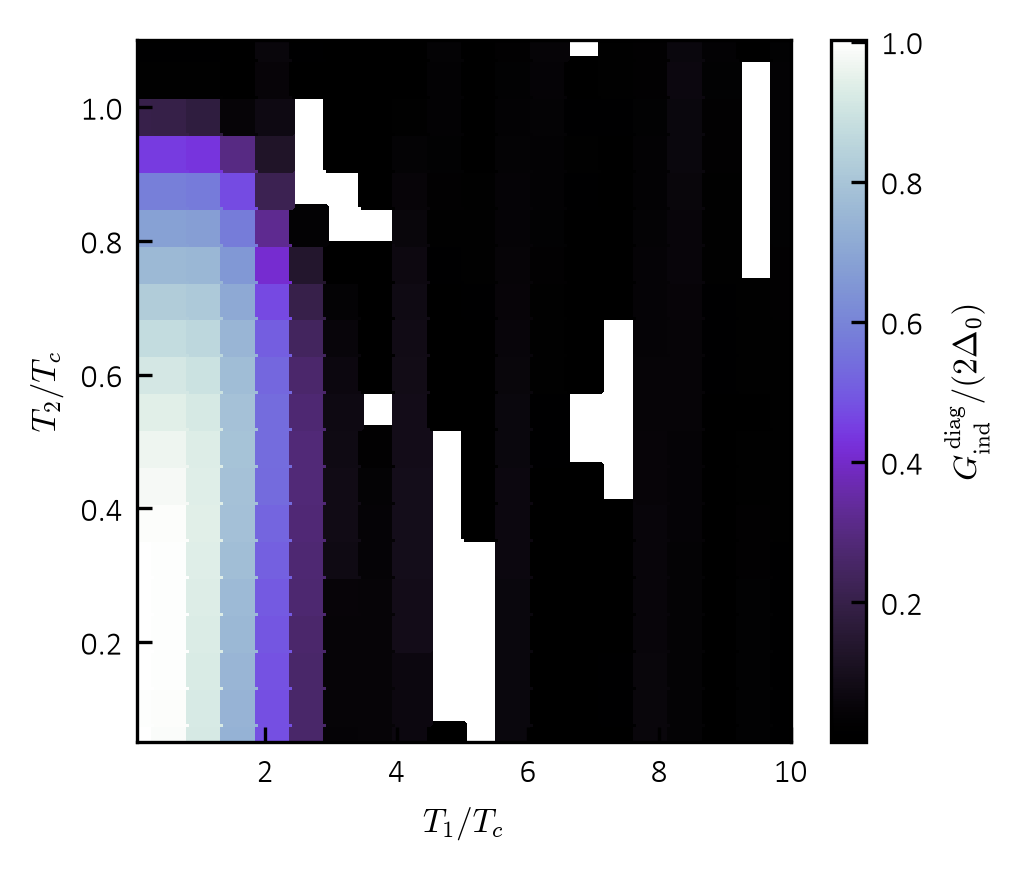

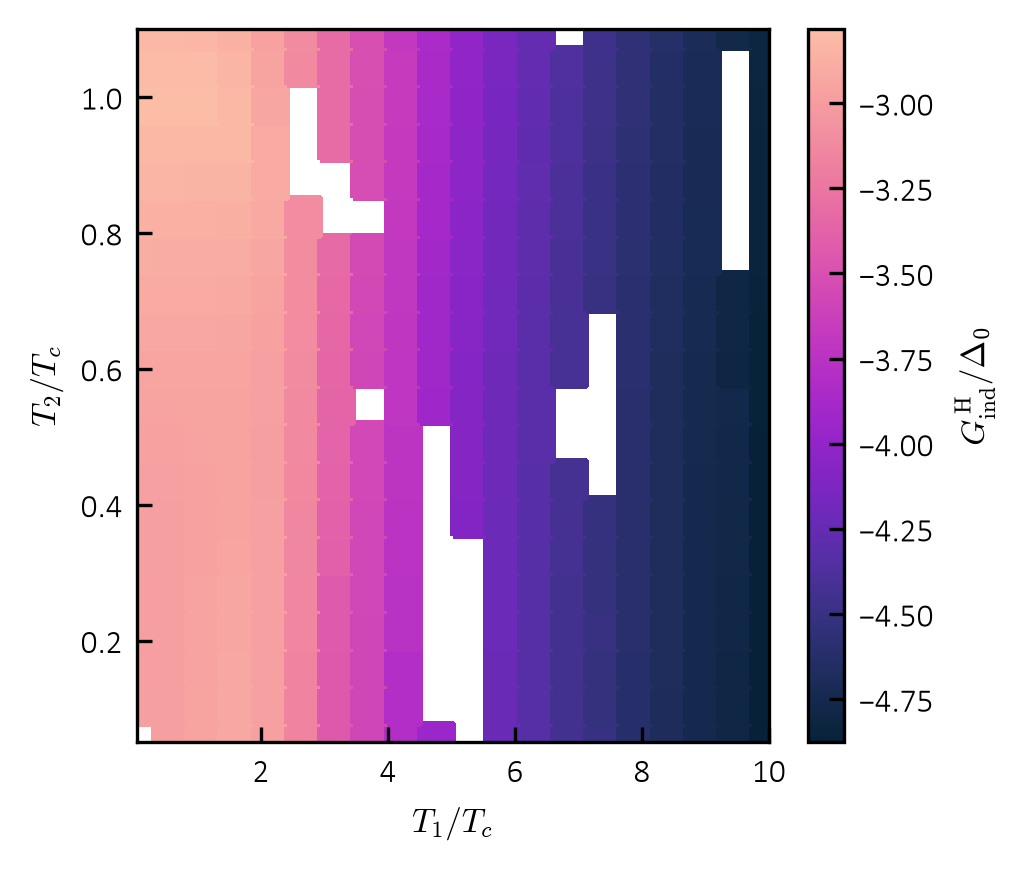

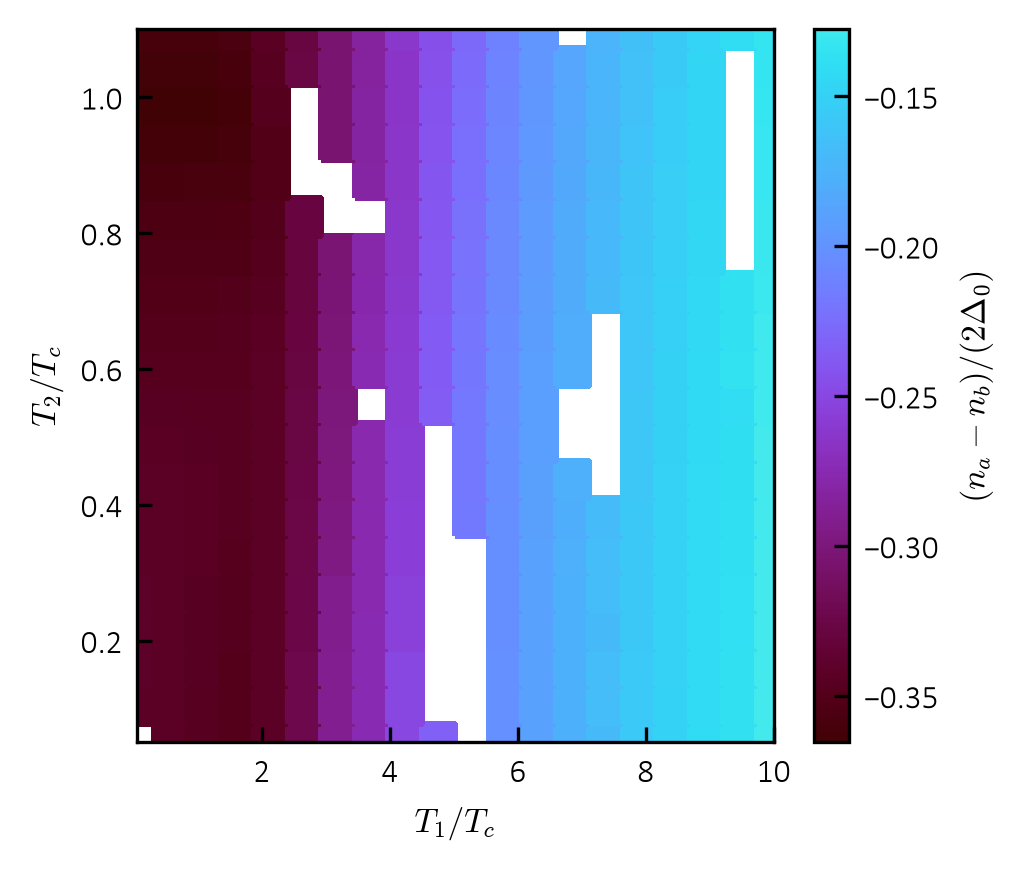

In [223]:
from phase_map_plots import scan_rect_ph, plot_maps_rect

r1a = np.linspace(0.05, 10., 20)            # T1/Tc
r2a = np.linspace(0.05, 1.1, 20)            # T2/Tc
zr = scan_rect_ph(bd, p, eq, op, r1a * tc, r2a * tc, d0, m0,
                  {**sk, "prog": False}, ov=ov)
plot_maps_rect(pt, r1a, r2a, zr, d0)

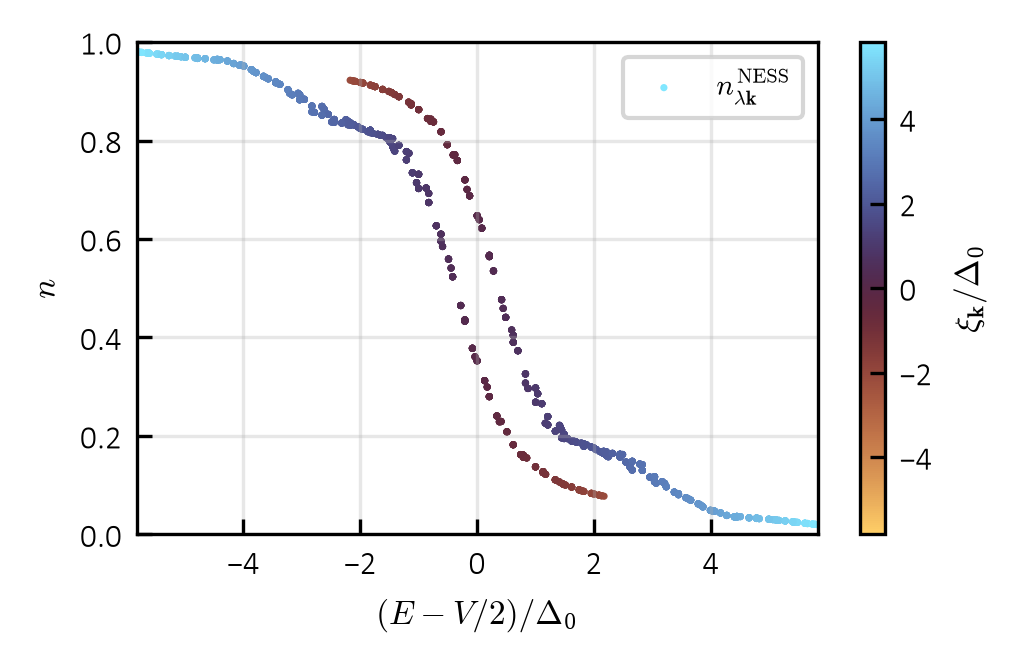

In [224]:
xi = 0.5 * (np.asarray(so.st.eah) - np.asarray(so.st.ebh))
xs2 = np.tile(xi, 2) / d0                       # same xi for both bands
lim = np.abs(xs2).max()
with pt.figure(h=0.65) as fg:
    a = fg.ax
    im = a.scatter(ef / d0, nn, c=xs2, s=3, cmap=cmaps.managua, vmin=-lim, vmax=lim,
                   edgecolors="none", label=r"$n_{\lambda\mathbf{k}}^{\mathrm{NESS}}$")
    format_ax(a, x=xs, xlabel=r"$(E-V/2)/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)
    fg.colorbar(im, r"$\xi_\mathbf{k}/\Delta_0$", ax=a)

In [225]:
for lam, lb in enumerate(("alpha", "beta")):
    x, y = np.asarray(st.e[lam]), np.asarray(so.n[lam])
    ok = (y > 0.05) & (y < 0.95)
    sl, ic = np.polyfit(x[ok], np.log(1.0 / y[ok] - 1.0), 1)
    print(f"{lb}: T/Tc = {1.0 / sl / tc:.3f}, mu/D0 = {-ic / sl / d0:.3f}")

alpha: T/Tc = 3.195, mu/D0 = -0.842
beta: T/Tc = 3.195, mu/D0 = 0.842
